# Initial Setup

In [34]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
from sklearn.ensemble import RandomForestClassifier
# make_scorer source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html
from sklearn.metrics import make_scorer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns


# Source: https://imbalanced-learn.org/stable/over_sampling.html
from imblearn.over_sampling import SMOTENC, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE

import src.utils.utils as ut
import src.utils.model_prep_eval as mod_prep

In [2]:
wine_df = pd.read_csv(ut.get_project_file_path("src", "data", "transformed", "wines_clean.csv"))
wine_df = wine_df.reset_index(drop=False,)
wine_df = wine_df.rename(columns={"index": "wine_id"})
wine_df.head(3)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,San Carlos,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,0,0,0,0,0,0,0,0,0,0
1,1,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2015.0,Catena Zapata,4.7,297.0,675.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0
2,2,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2017.0,Catena Zapata,4.7,219.0,580.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0


In [5]:
users_data_complete = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_07_0.008_0.65_n400_repchs.pkl"))
users_data = users_data_complete.dropna()
users_data.head(3)

,event_timestamp,user_id,wine_id,user_input,metrics_local,metrics_global,liked,prob_like
0,2023-08-05,0,520.0,"{'meal': 'Tarta de Vegetales y Queso', 'main_p...",rating_rscld 0.0 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,1.0,0.964301
1,2023-09-06,0,1002.0,"{'meal': 'Pasta con Salsa Mixta', 'main_pairin...",rating_rscld 0.0 price_rscld ...,rating_rscld_gbl -1.666667 price_rscl...,0.0,0.695687
2,2023-09-28,0,1640.0,"{'meal': 'Milanesa de Pollo', 'main_pairing': ...",rating_rscld 1.0 price_rscld ...,rating_rscld_gbl 0.0 price_rscl...,1.0,0.861755


In [6]:
# Agrega la información de los usuarios al df de vinos
recommend_df = pd.merge(wine_df, users_data, how="inner", on="wine_id")
recommend_df.head(3)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,Uco Valley,Vale dos Vinhedos,Vista Flores,event_timestamp,user_id,user_input,metrics_local,metrics_global,liked,prob_like
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,0,0,0,2023-10-16,259,"{'meal': 'Pechuga de Pollo Rellena', 'main_pai...",rating_rscld 2.5 price_rscld ...,rating_rscld_gbl 2.666667 price_rscl...,1.0,0.771509
1,22,https://www.vivino.com/US/en/bodegas-bianchi-e...,Enzo Bianchi Gran Corte,2020.0,Bodegas Bianchi,4.5,25.0,70.00,0.8112,0.5782,...,0,0,0,2022-06-01,6,"{'meal': 'Lasagna de Verduras', 'main_pairing'...",rating_rscld 1.0 price_rscld ...,rating_rscld_gbl 1.666667 price_rscl...,1.0,0.889008
2,22,https://www.vivino.com/US/en/bodegas-bianchi-e...,Enzo Bianchi Gran Corte,2020.0,Bodegas Bianchi,4.5,25.0,70.00,0.8112,0.5782,...,0,0,0,2023-06-11,115,"{'meal': 'Pasta con Salsa de Tomate', 'main_pa...",rating_rscld 1.0 price_rscld ...,rating_rscld_gbl 1.666667 price_rscl...,1.0,0.975927


In [7]:
# Agrega si el vino tenia match con el main pairing del user
recommend_df["user_main_pairing"] = recommend_df["user_input"].apply(lambda x: x["main_pairing"])
recommend_df["has_user_main_pairing"] = recommend_df.apply(lambda row: 1 if row[row["user_main_pairing"]]==1 else 0, axis=1)

# Agrega los límites inferiores y superiores de sabor según la decisión del usuario
taste_list = ["body", "tannins", "sweetness", "acidity"]
for taste in taste_list:
    recommend_df["user_" + taste + "_min"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][0])
    recommend_df["user_" + taste + "_max"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][1])

# Agrega la distancia fuzzy sin escalar entre el sabor de vino y las preferencias del usuario
recommend_df["user_taste_distance_raw"] = recommend_df["metrics_global"].apply(lambda x: x["taste_distance_raw_gbl"])
recommend_df.head(3)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,has_user_main_pairing,user_body_min,user_body_max,user_tannins_min,user_tannins_max,user_sweetness_min,user_sweetness_max,user_acidity_min,user_acidity_max,user_taste_distance_raw
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,1,0.204380,0.544781,0.333468,0.570218,0.247411,0.342750,0.041018,0.468561,0.258805
1,22,https://www.vivino.com/US/en/bodegas-bianchi-e...,Enzo Bianchi Gran Corte,2020.0,Bodegas Bianchi,4.5,25.0,70.00,0.8112,0.5782,...,1,0.929781,0.955912,0.527307,0.656612,0.219397,0.307674,0.707214,0.778835,0.405143
2,22,https://www.vivino.com/US/en/bodegas-bianchi-e...,Enzo Bianchi Gran Corte,2020.0,Bodegas Bianchi,4.5,25.0,70.00,0.8112,0.5782,...,1,0.492409,0.862190,0.527307,0.656612,0.307674,0.391714,0.604475,0.655587,0.159861


In [8]:
# Carga de uvas, regions y pairings
grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))
grapes_list = list(grapes["grapes"])
region = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "region.csv"))
region_list = list(region["region"])
pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))
pairings_list = list(pairings["pairings"])

# Quita columnas no útiles para la predicción
model_df = recommend_df.drop(columns=[
    "event_timestamp", "wine_id", "wine_link", "name", "winery", "style", "image",               # Original df columns
    "user_id", "user_input", "metrics_local", "metrics_global", "prob_like", "user_main_pairing" # User data columns
]).copy()      

# Quita columnas one hot (uvas y regions)
model_df_nooh = model_df.drop(columns=(grapes_list + region_list)).copy() # One-hot columns

# Quita columnas categóricas (maridajes)
model_df_nocat = model_df_nooh.drop(columns=pairings_list) # Categorical column

# Verifica las columnas
print(model_df.columns, "\n", model_df_nooh.columns, "\n", model_df_nocat.columns)

Index(['year', 'rating', 'rating_qty', 'price', 'body', 'tannins', 'sweetness',
       'acidity', 'alcohol', 'ageing',
       ...
       'has_user_main_pairing', 'user_body_min', 'user_body_max',
       'user_tannins_min', 'user_tannins_max', 'user_sweetness_min',
       'user_sweetness_max', 'user_acidity_min', 'user_acidity_max',
       'user_taste_distance_raw'],
      dtype='object', length=124) 
 Index(['year', 'rating', 'rating_qty', 'price', 'body', 'tannins', 'sweetness',
       'acidity', 'alcohol', 'ageing', 'black fruit', 'citrus', 'dried fruit',
       'earthy', 'floral', 'oaky', 'red fruit', 'spices', 'tree fruit',
       'tropical', 'vegetal', 'yeasty', 'any junk food will do', 'aperitif',
       'appetizers and snacks', 'beef', 'blue cheese', 'cured meat',
       'game (deer, venison)', 'goat's milk cheese', 'lamb', 'lean fish',
       'mature and hard cheese', 'mild and soft cheese', 'mushrooms', 'pasta',
       'pork', 'poultry', 'rich fish (salmon, tuna etc)', 'shellf

In [9]:
# Instanciación de modelo RandomForest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features="sqrt", class_weight="balanced")

## Evaluación Económica

### ✅ True Positive (TP)
Se recomienda un vino y al usuario le gusta.

El usuario tiene mayor probabilidad de quedarse (menor churn), por lo tanto se captura el valor esperado del ticket de recompra.

Fórmula:

$$\text{Valor}_{TP} = \text{AvgTkt} \times (1 - \text{Churn}_{like})$$

### ✅ True Negative (TN)
Se descarta un vino que al usuario no le gustaría, y se recomienda otro que podría gustarle.

Este caso depende de la precisión del modelo (Precision) para acertar la segunda recomendación. Se gana la diferencia entre:

- El valor esperado si se acertara la segunda recomendación.

- El valor perdido si se hubiera ofrecido el vino "malo" original.

Fórmula:
$$ \text{Valor}_{TN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{dislike}) \right)$$

### ❌ False Positive (FP)
Se recomienda un vino que no le gusta al usuario.

Esto aumenta fuertemente la probabilidad de churn, y se pierde el valor del ticket.

Fórmula:

$$\text{Valor}_{FP} = - \text{AvgTkt} \times \text{Churn}_{dislike}$$

### ❌ False Negative (FN)
Se descarta un vino que sí le habría gustado al usuario, y se le recomienda otro con menor probabilidad de acierto.

Se pierde el valor que se habría capturado si se recomendaba el vino correcto, ajustado por la incertidumbre de la nueva recomendación.

Fórmula:

$$\text{Valor}_{FN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{like}) \right)$$

### ⚠️ Notas:

- Precisión representa la probabilidad de que la segunda recomendación, luego de identificar una opción no recomendable, sea acertada.

In [11]:
# Obtención de parámetros utilizados para generar la data sintética
simulation_params = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_07_0.008_0.65_n400_repchs_params.pkl"))
avg_tkt = model_df_nooh["price"].mean()
churn_like = simulation_params["liked_churn_rate"]
churn_dislike = simulation_params["disliked_churn_rate"]
print("Ticket Promedio:", avg_tkt, "\nChurn Like:", churn_like, "\nChurn Dislike:", churn_dislike)

Ticket Promedio: 20.14312563840654 
Churn Like: 0.008 
Churn Dislike: 0.65


# Evaluación de Modelos

In [ ]:
# Entrenamiento y evaluación de modelo RandomForest con oversample categórico (SMOTENC)
idx_cat_features = [model_df_nooh.columns.get_loc(col) for col in pairings_list]

X_smotenc, y_smotenc = mod_prep.oversample_df(
    df=model_df_nooh,
    sampling_object=SMOTENC,
    random_state=0,
    categorical_features=idx_cat_features
)

results_smotenc = mod_prep.train_test_model(
    X=X_smotenc,
    y=y_smotenc,
    model_object=rf_model,
    test_size=0.2,
    random_state=0,
    stratify=y_smotenc
)

display(Markdown("# SMOTENC"))
mod_prep.print_model_results(results_smotenc)
cm_pred = results_smotenc["cm_pred"]
eco_score = mod_prep.economic_score(
    conf_matrix=cm_pred,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

In [ ]:
# Entrenamiento y evaluación de modelo RandomForest con distintos métodos de oversample
sampling_objects = [SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE]

for obj in sampling_objects:

    X_resampled, y_resampled = mod_prep.oversample_df(
        df=model_df_nocat,
        sampling_object=obj,
        random_state=0,
    )

    results_resampled = mod_prep.train_test_model(
        X=X_resampled,
        y=y_resampled,
        model_object=rf_model,
        test_size=0.2,
        random_state=0,
        stratify=y_resampled
    )

    display(Markdown(f"# {obj.__name__}"))
    mod_prep.print_model_results(results_resampled)
    cm_pred = results_resampled["cm_pred"]
    eco_score = mod_prep.economic_score(
        conf_matrix=cm_pred,
        avg_tkt=avg_tkt,
        churn_like=churn_like,
        churn_dislike=churn_dislike
        )
    print("Gain from model: $", round(eco_score), sep="")

# GridSearchCV

In [9]:
def economic_scorer_func(y_true, y_pred, avg_tkt, churn_like, churn_dislike):
    cmax = confusion_matrix(y_true, y_pred)
    eco_score = mod_prep.economic_score(
        conf_matrix=cmax,
        avg_tkt=avg_tkt,
        churn_like=churn_like,
        churn_dislike=churn_dislike
    )
    return eco_score

economic_scorer = make_scorer(
    economic_scorer_func,
    greater_is_better=True,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
)

# rf_param_grid = {
#     "n_estimators": [100, 250, 500],
#     "max_depth": [6, 10, 14],
#     "min_samples_split": [2, 4, 6],
#     "criterion": ("gini", "entropy", "log_loss"),
#     "class_weight": [None, "balanced", "balanced_subsample"]
# }

rf_param_grid = {
    "n_estimators": [300, 325, 350],
    "max_depth": [8],
    "min_samples_split": [2],
    "criterion": ["gini"],
    "class_weight": ["balanced"]
}

grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring=economic_scorer,
    cv=5
)

In [ ]:

X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nocat,
    sampling_object=SMOTE,
    random_state=0,
)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=0,
    stratify=y_resampled
)

grid.fit(X=X_train, y=y_train)
best_model = grid.best_estimator_
best_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 8,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

# SMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.92      0.91      0.92      1245
         1.0       0.91      0.93      0.92      1246

    accuracy                           0.92      2491
   macro avg       0.92      0.92      0.92      2491
weighted avg       0.92      0.92      0.92      2491



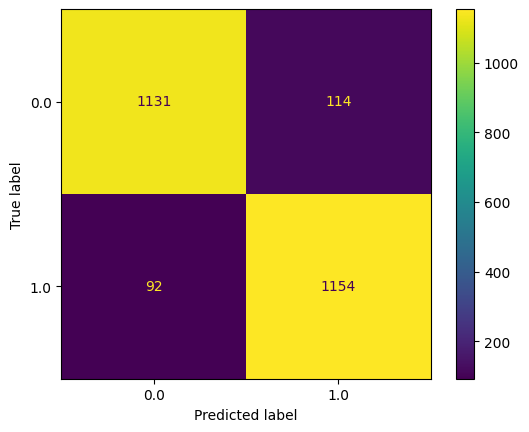

AUC Train: 0.9772247900107653

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.79      0.80      0.80       312
         1.0       0.80      0.79      0.79       311

    accuracy                           0.80       623
   macro avg       0.80      0.80      0.80       623
weighted avg       0.80      0.80      0.80       623



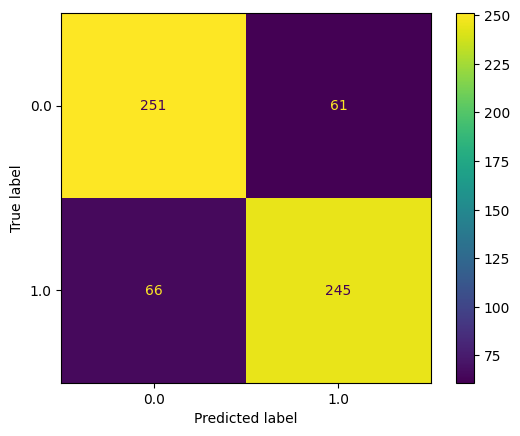

AUC Train: 0.8854243960755215
Gain from model: $5253


In [35]:
results_resampled = mod_prep.train_test_model(
    X=X_resampled,
    y=y_resampled,
    model_object=best_model,
    test_size=0.2,
    random_state=0,
    stratify=y_resampled
)

display(Markdown(f"# {SMOTE.__name__}"))
mod_prep.print_model_results(results_resampled)
cm_pred = results_resampled["cm_pred"]
eco_score = mod_prep.economic_score(
    conf_matrix=cm_pred,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

# Learning Curves

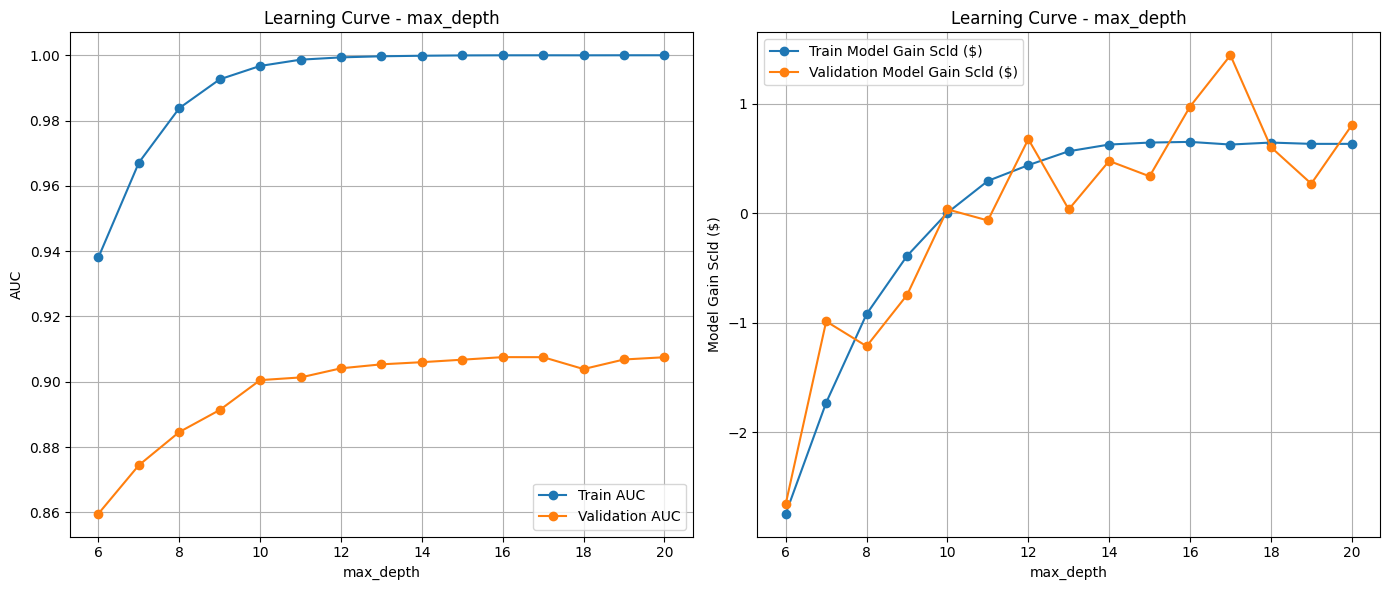

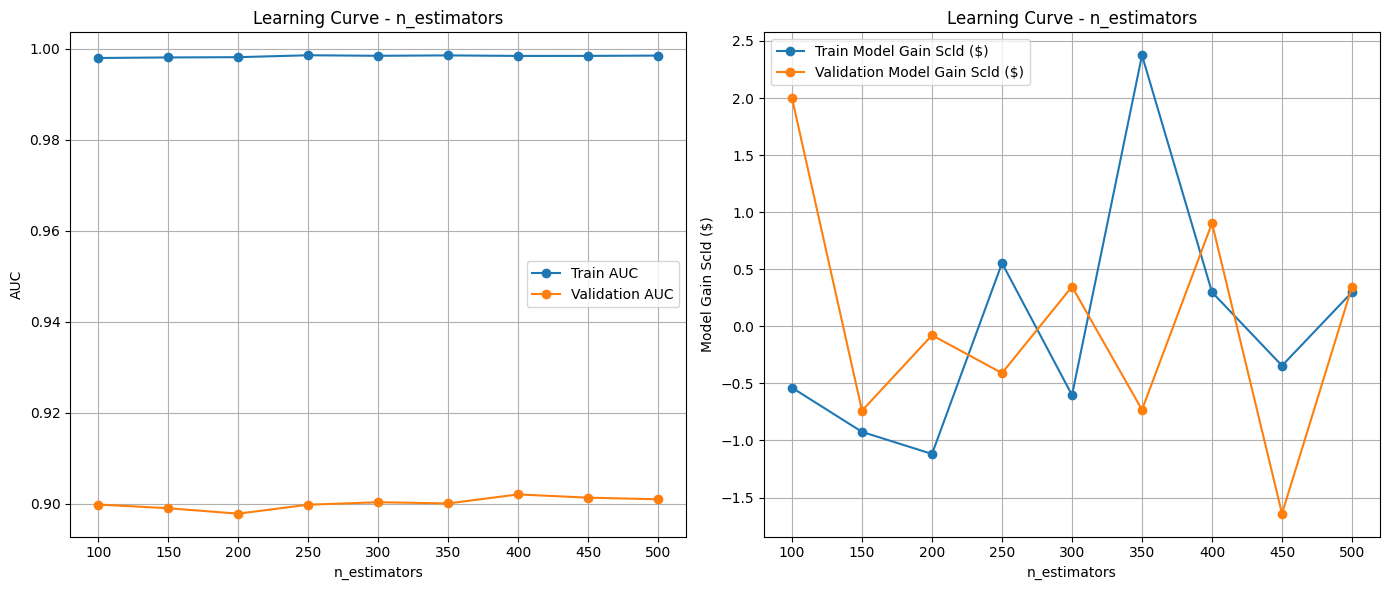

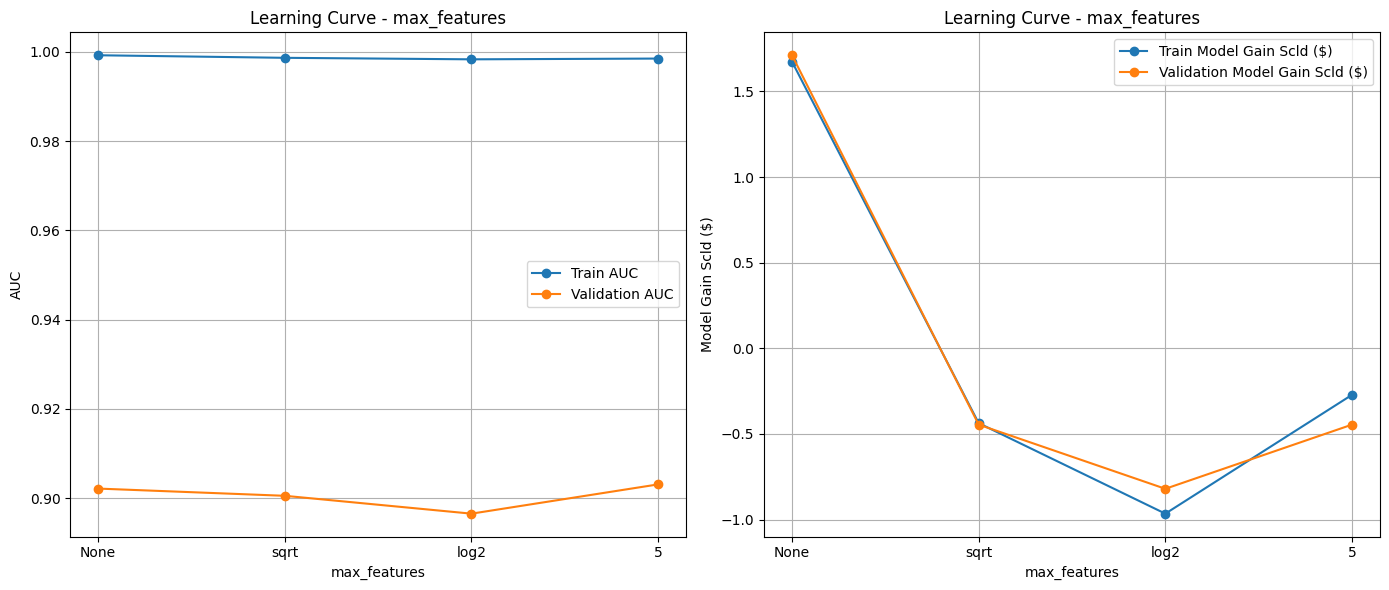

In [10]:
from sklearn.metrics import roc_auc_score
from scipy import stats

# Oversampling de clase minoritaria
X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nocat,
    sampling_object=SMOTE,
    random_state=0
)

# Partición en train, validation y test
X_trainval, X_test, y_trainval, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=0, stratify=y_resampled)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=0, stratify=y_trainval)

params_values = {
    "max_depth": range(6,21),
    "n_estimators": range(100,550,50),
    #"min_samples_split": range(2, 5),
    #"min_samples_leaf": range(2, 5),
    "max_features": [None, "sqrt", "log2", 5]
}

for param, values in params_values.items():
    # Crear listas de scores vacías para cada parámetro
    auc_train_scores = []
    auc_val_scores = []
    eco_train_scores = []
    eco_val_scores = []
    
    # Crear modelo con hiperparámetros default
    model = RandomForestClassifier(n_estimators=300, max_depth=11, min_samples_split=3, min_samples_leaf=1)
    
    for val in values:
        # Setear el valor del parámetro pasado en params_values
        setattr(model, param, val)

        # Entrenar el modelo
        model.fit(X_train, y_train)

        # Calcular y hacer append de AUC en train y validation
        pred_prob_train = model.predict_proba(X_train)[:, 1]
        auc_train = roc_auc_score(y_train, pred_prob_train)
        
        pred_prob_val = model.predict_proba(X_val)[:, 1]
        auc_val = roc_auc_score(y_val, pred_prob_val)

        auc_train_scores.append(auc_train)
        auc_val_scores.append(auc_val)

        # Calcular y hacer append de economic score en train y validation
        pred_train = model.predict(X_train)
        train_cm = confusion_matrix(y_train, pred_train)
        eco_train = mod_prep.economic_score(train_cm, avg_tkt, churn_like, churn_dislike)

        pred_val = model.predict(X_val)
        val_cm = confusion_matrix(y_val, pred_val)
        eco_val = mod_prep.economic_score(val_cm, avg_tkt, churn_like, churn_dislike)

        eco_train_scores.append(eco_train)
        eco_val_scores.append(eco_val)


    eco_train_scores_z = stats.zscore(eco_train_scores)
    eco_val_scores_z = stats.zscore(eco_val_scores)

    # Plotear Learning Curves
    param_scores_pairs = {
        "AUC": [auc_train_scores, auc_val_scores],
        "Model Gain Scld ($)": [eco_train_scores_z, eco_val_scores_z]
    }

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    if None in values:
        none_idx = values.index(None)
        values[none_idx] = "None"

    for i, (metric, pair) in enumerate(param_scores_pairs.items()):
        ax = axes[i]
        ax.plot(values, pair[0], label=f"Train {metric}", marker="o")
        ax.plot(values, pair[1], label=f"Validation {metric}", marker="o")
        ax.set_xlabel(param)
        ax.set_ylabel(f"{metric}")
        ax.set_title(f"Learning Curve - {param}")
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()


# SMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97      1245
         1.0       0.97      0.98      0.97      1246

    accuracy                           0.97      2491
   macro avg       0.97      0.97      0.97      2491
weighted avg       0.97      0.97      0.97      2491



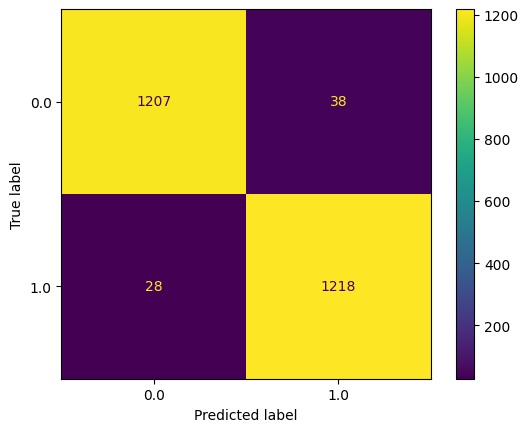

AUC Train: 0.9971394405873897

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.84      0.81      0.82       312
         1.0       0.81      0.85      0.83       311

    accuracy                           0.83       623
   macro avg       0.83      0.83      0.83       623
weighted avg       0.83      0.83      0.83       623



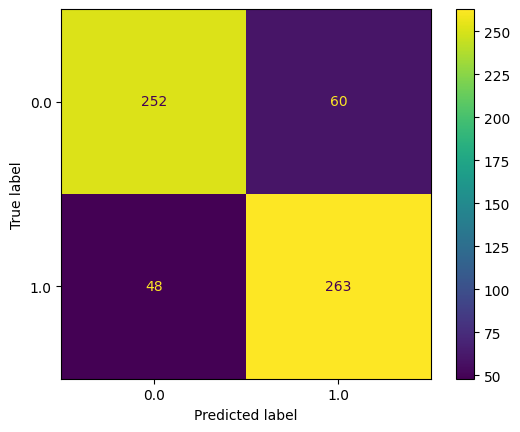

AUC Test: 0.9060979882925221
Gain from model: $5885


In [12]:
# Test Model Selected from Learning Curves
rf_model2 = RandomForestClassifier(n_estimators=300, max_depth=11, min_samples_split=3, min_samples_leaf=1)

X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nocat,
    sampling_object=SMOTE,
    random_state=42,
)

results_resampled = mod_prep.train_test_model(
    X=X_resampled,
    y=y_resampled,
    model_object=rf_model2,
    test_size=0.2,
    random_state=0,
    stratify=y_resampled
)

display(Markdown(f"# {SMOTE.__name__}"))
mod_prep.print_model_results(results_resampled)
cm_pred = results_resampled["cm_pred"]
eco_score = mod_prep.economic_score(
    conf_matrix=cm_pred,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

# Feature Selection

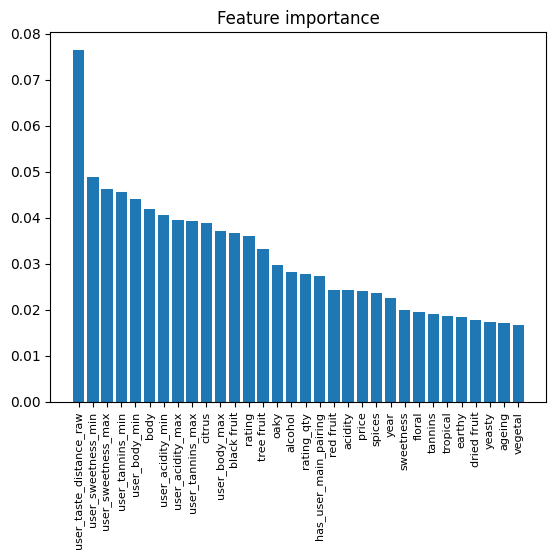

In [13]:
model_ft_imp = {}

for feature, importance in zip(rf_model2.feature_names_in_, rf_model2.feature_importances_):
    model_ft_imp[feature] = importance

model_ft_imp = dict(sorted(model_ft_imp.items(), key=lambda item: item[1], reverse=True))

plt.bar(model_ft_imp.keys(), model_ft_imp.values())
plt.xticks(size=8, rotation=90)
plt.title("Feature importance")
plt.show()

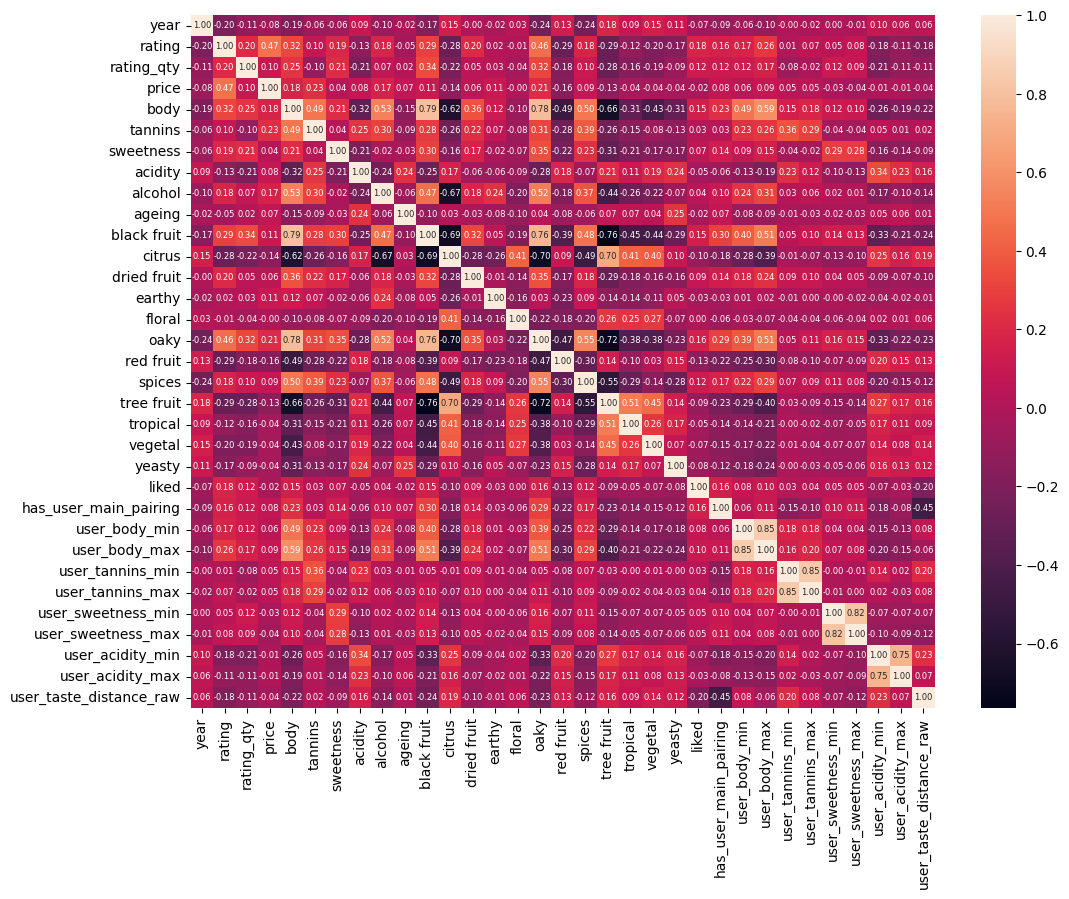

In [ ]:
corr_mtx = model_df_nocat.corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr_mtx, annot=True, fmt=".2f", annot_kws={"fontsize": 6})
plt.show()



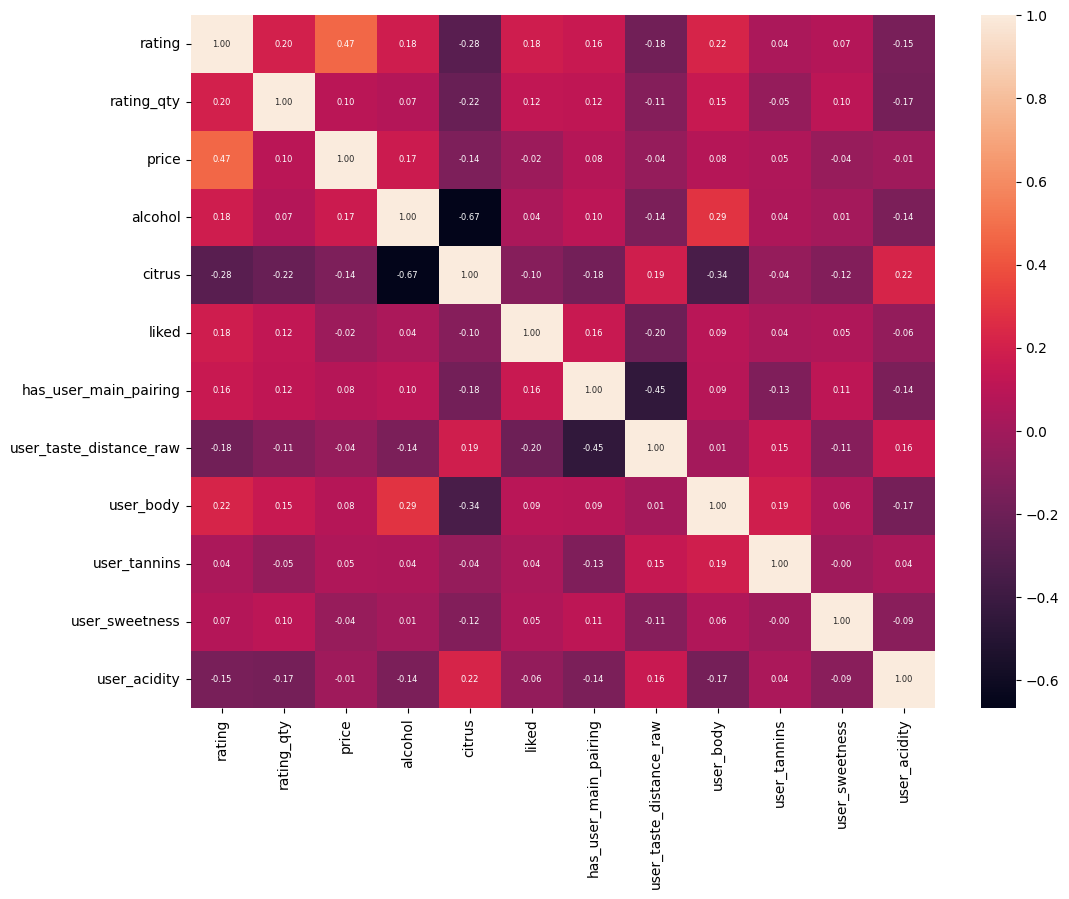

In [30]:
no_collinear_df = model_df_nocat.copy()
no_collinear_df["user_body"] = no_collinear_df[["user_body_max", "user_body_min"]].mean(axis=1)
no_collinear_df["user_tannins"] = no_collinear_df[["user_tannins_max", "user_tannins_min"]].mean(axis=1)
no_collinear_df["user_sweetness"] = no_collinear_df[["user_sweetness_max", "user_sweetness_min"]].mean(axis=1)
no_collinear_df["user_acidity"] = no_collinear_df[["user_acidity_max", "user_acidity_min"]].mean(axis=1)
no_collinear_df = no_collinear_df.drop(columns=[
    "user_body_max", "user_body_min", "user_tannins_max", "user_tannins_min",
    "user_sweetness_max", "user_sweetness_min", "user_acidity_max", "user_acidity_min",
    "body", "tannins", "sweetness", "acidity", 'red fruit', 'spices', 'year', 'floral',
    'tropical', 'earthy', 'dried fruit', 'yeasty', 'ageing', 'vegetal', 'tree fruit', 'oaky', "black fruit"
])

corr_mtx_nocol = no_collinear_df.corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr_mtx_nocol, annot=True, fmt=".2f", annot_kws={"fontsize": 6})
plt.show()

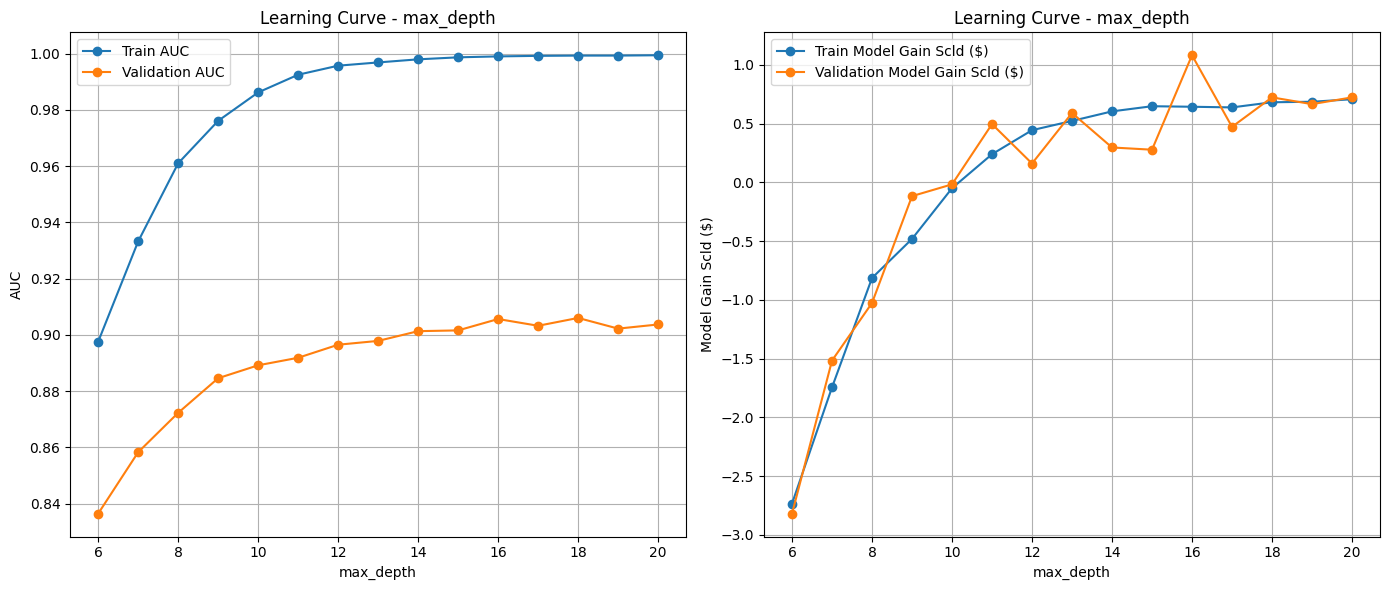

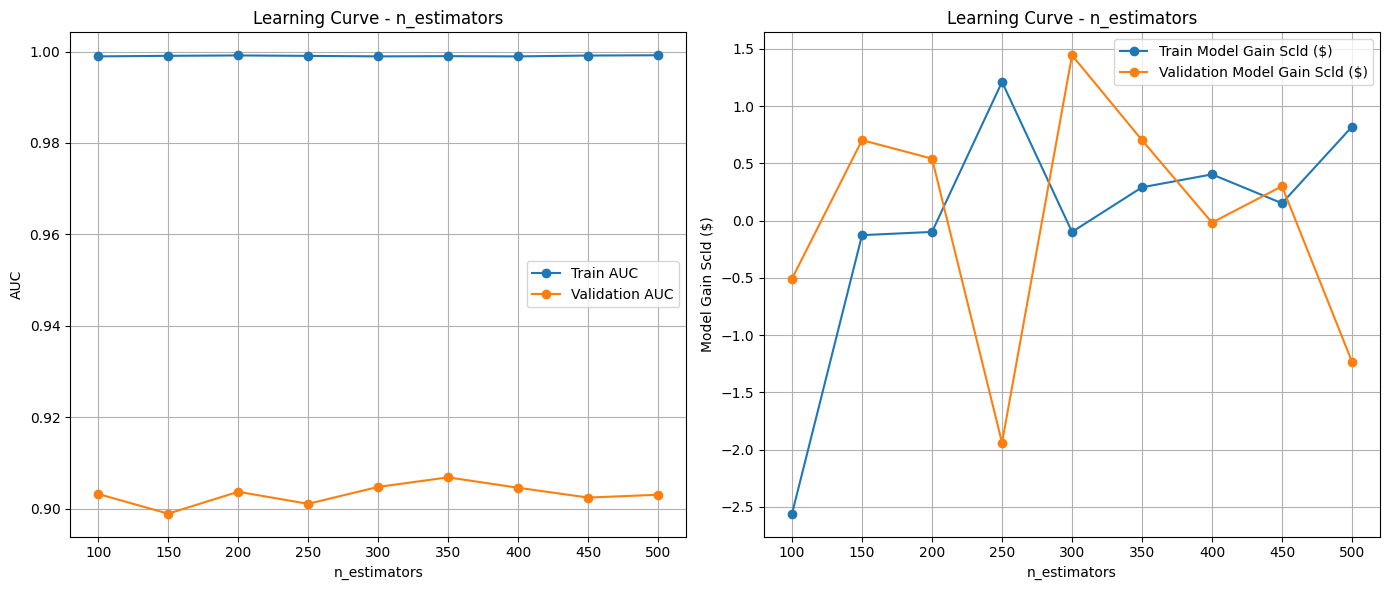

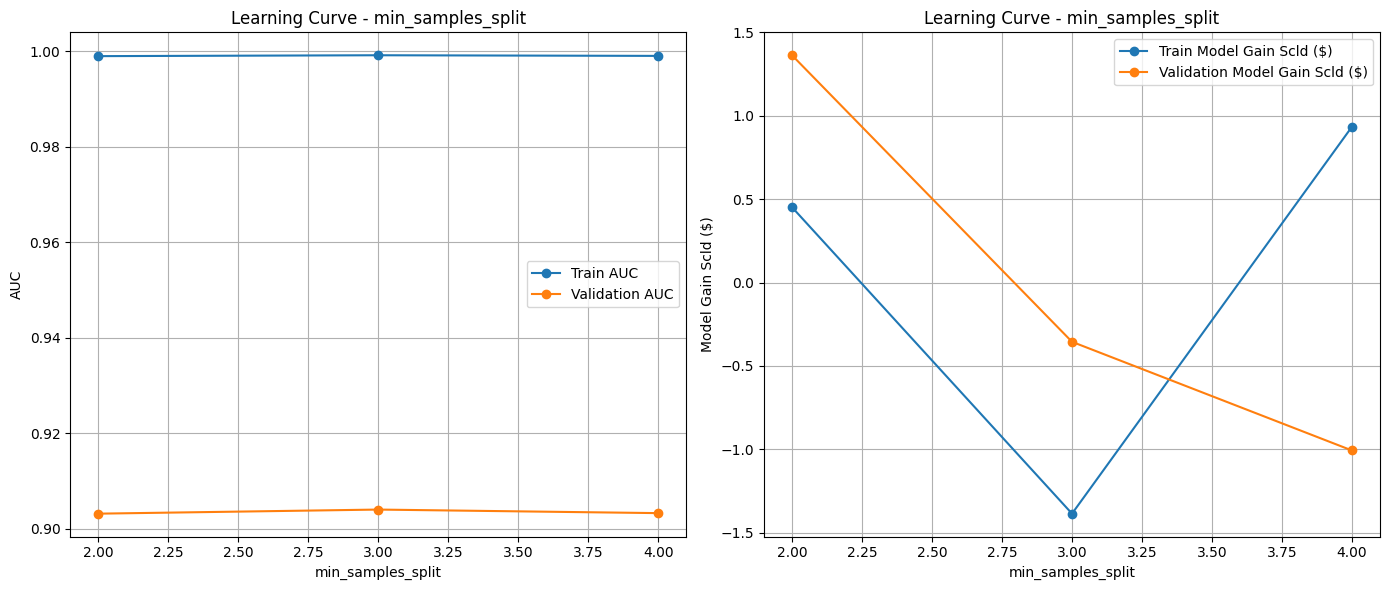

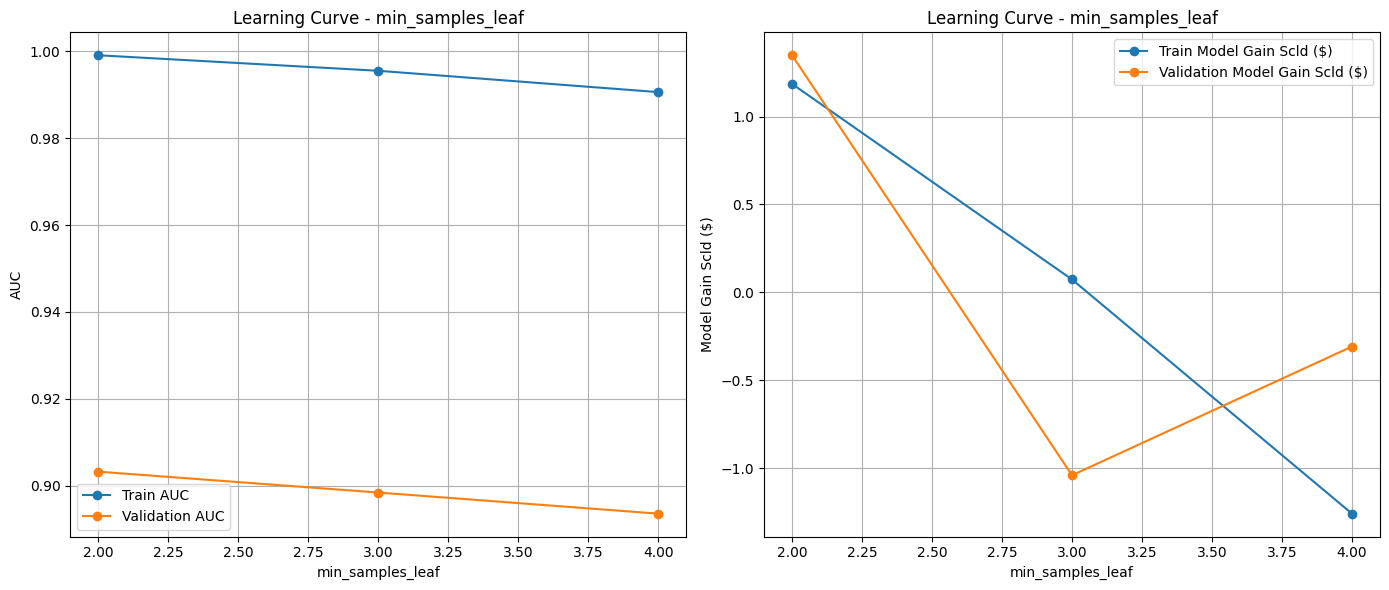

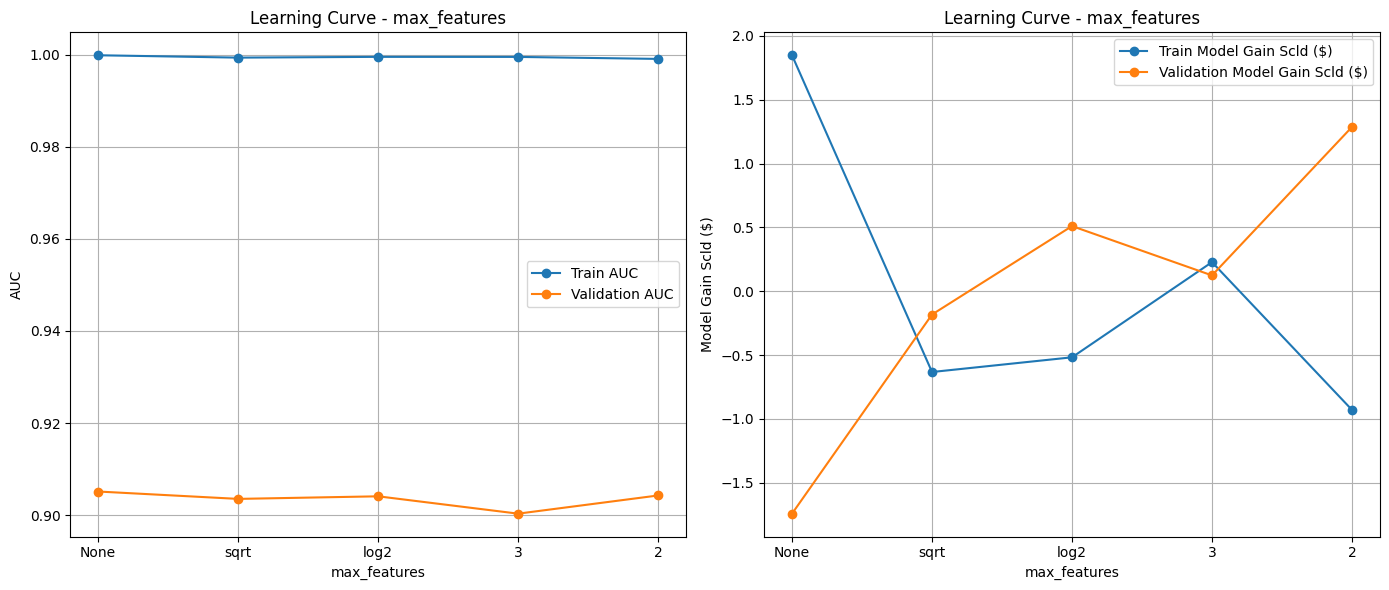

In [ ]:
from sklearn.metrics import roc_auc_score
from scipy import stats

# Oversampling de clase minoritaria
X_resampled, y_resampled = mod_prep.oversample_df(
    df=no_collinear_df,
    sampling_object=ADASYN
)

# Partición en train, validation y test
X_trainval, X_test, y_trainval, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=0, stratify=y_resampled)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=0, stratify=y_trainval)

params_values = {
    "max_depth": range(6,21),
    "n_estimators": range(100,550,50),
    "min_samples_split": range(2, 5),
    "min_samples_leaf": range(2, 5),
    "max_features": [None, "sqrt", "log2", 3, 2]
}

for param, values in params_values.items():
    # Crear listas de scores vacías para cada parámetro
    auc_train_scores = []
    auc_val_scores = []
    eco_train_scores = []
    eco_val_scores = []
    
    # Crear modelo con hiperparámetros default
    model = RandomForestClassifier(n_estimators=300, max_depth=16, min_samples_split=2, min_samples_leaf=2, max_features=2)
    
    for val in values:
        # Setear el valor del parámetro pasado en params_values
        setattr(model, param, val)

        # Entrenar el modelo
        model.fit(X_train, y_train)

        # Calcular y hacer append de AUC en train y validation
        pred_prob_train = model.predict_proba(X_train)[:, 1]
        auc_train = roc_auc_score(y_train, pred_prob_train)
        
        pred_prob_val = model.predict_proba(X_val)[:, 1]
        auc_val = roc_auc_score(y_val, pred_prob_val)

        auc_train_scores.append(auc_train)
        auc_val_scores.append(auc_val)

        # Calcular y hacer append de economic score en train y validation
        pred_train = model.predict(X_train)
        train_cm = confusion_matrix(y_train, pred_train)
        eco_train = mod_prep.economic_score(train_cm, avg_tkt, churn_like, churn_dislike)

        pred_val = model.predict(X_val)
        val_cm = confusion_matrix(y_val, pred_val)
        eco_val = mod_prep.economic_score(val_cm, avg_tkt, churn_like, churn_dislike)

        eco_train_scores.append(eco_train)
        eco_val_scores.append(eco_val)


    eco_train_scores_z = stats.zscore(eco_train_scores)
    eco_val_scores_z = stats.zscore(eco_val_scores)

    # Plotear Learning Curves
    param_scores_pairs = {
        "AUC": [auc_train_scores, auc_val_scores],
        "Model Gain Scld ($)": [eco_train_scores_z, eco_val_scores_z]
    }

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    if None in values:
        none_idx = values.index(None)
        values[none_idx] = "None"

    for i, (metric, pair) in enumerate(param_scores_pairs.items()):
        ax = axes[i]
        ax.plot(values, pair[0], label=f"Train {metric}", marker="o")
        ax.plot(values, pair[1], label=f"Validation {metric}", marker="o")
        ax.set_xlabel(param)
        ax.set_ylabel(f"{metric}")
        ax.set_title(f"Learning Curve - {param}")
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()


In [48]:
# Oversampling de clase minoritaria
X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nooh,
    sampling_object=SMOTE
)

# Partición en train, validation y test
X_trainval, X_test, y_trainval, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=0, stratify=y_resampled)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=0, stratify=y_trainval)

model = RandomForestClassifier(n_estimators=300, max_depth=16, min_samples_split=2, min_samples_leaf=2, max_features=2)

selector = RFE(estimator = model, n_features_to_select=15, step=1)

selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_]

selected_features = selected_features.to_list()

selected_features.append("liked")

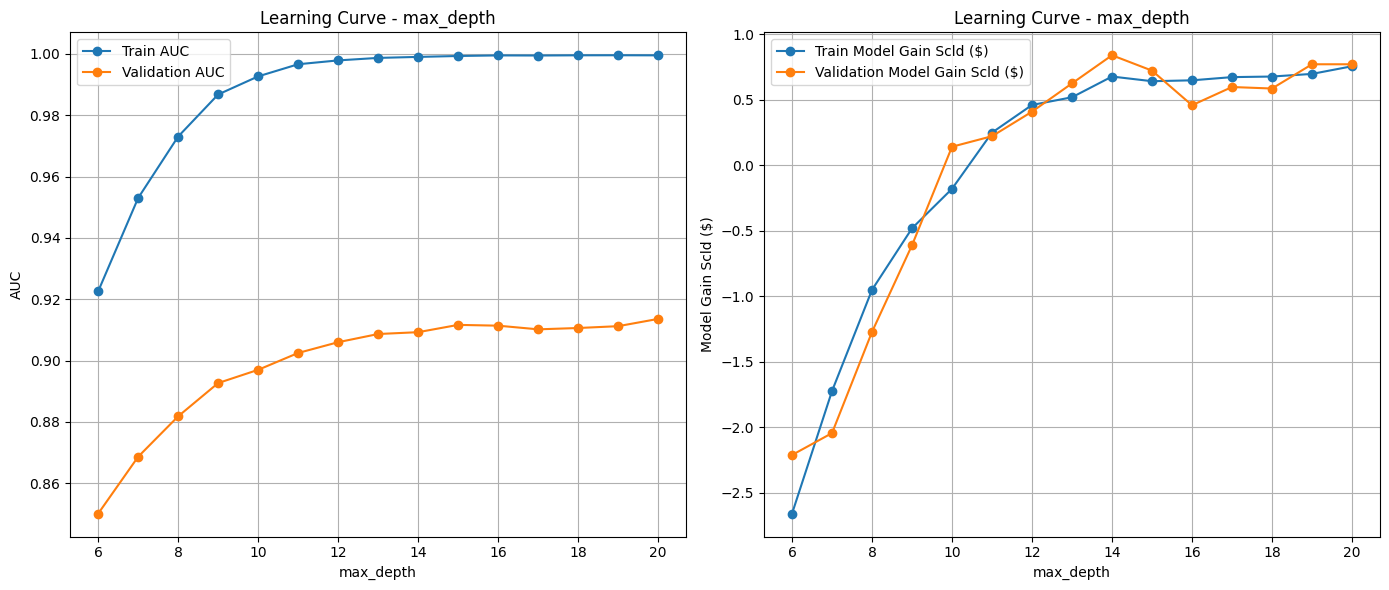

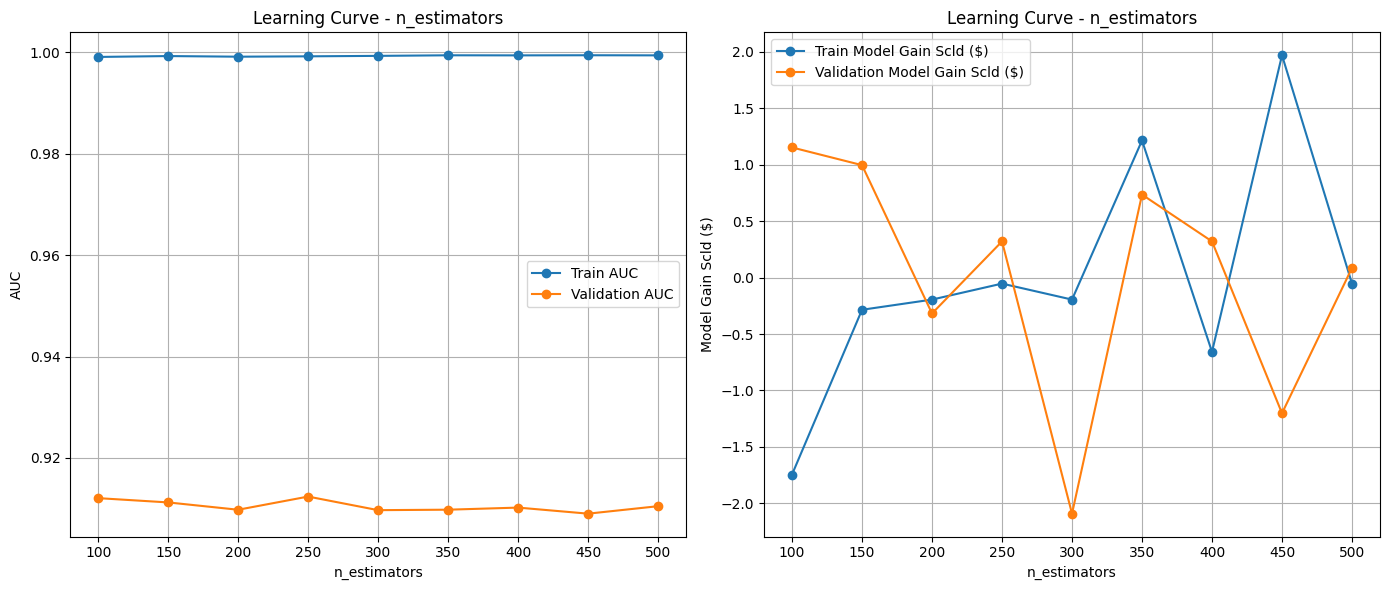

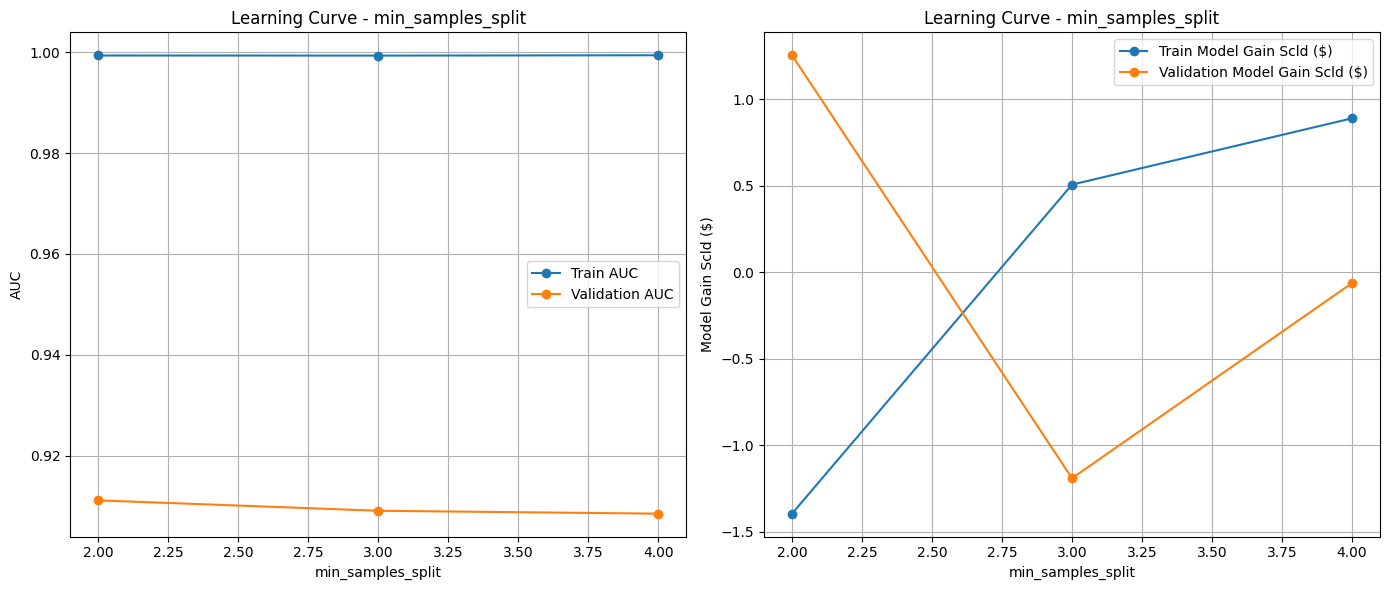

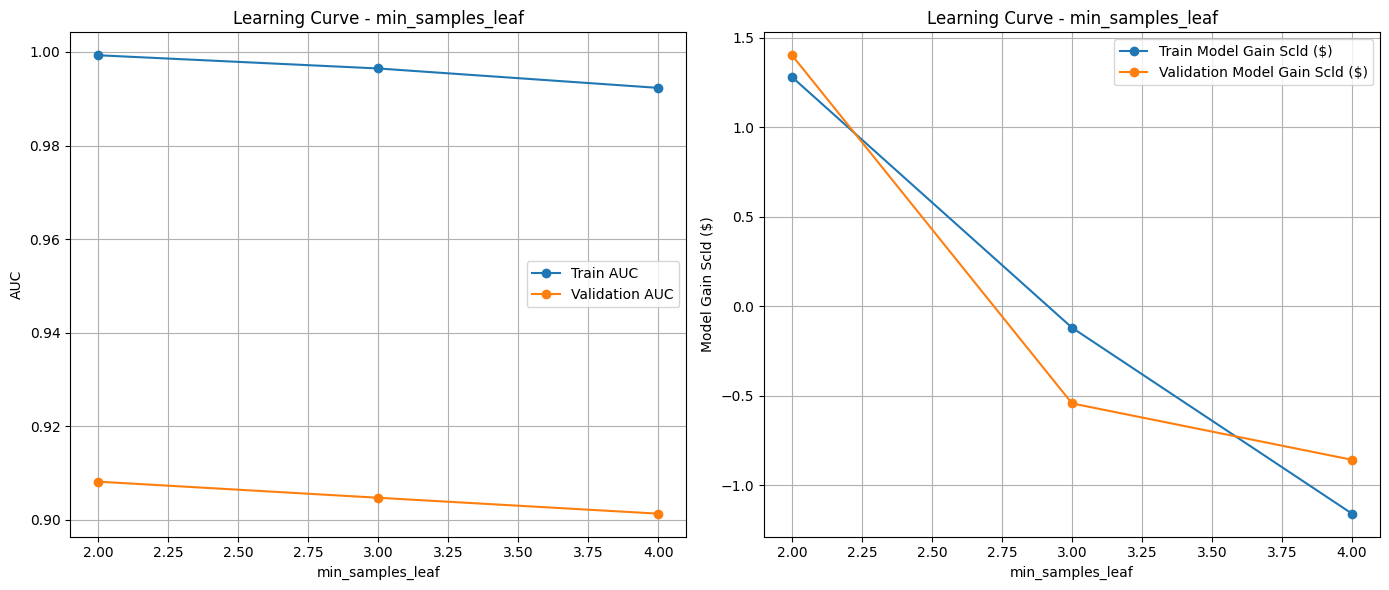

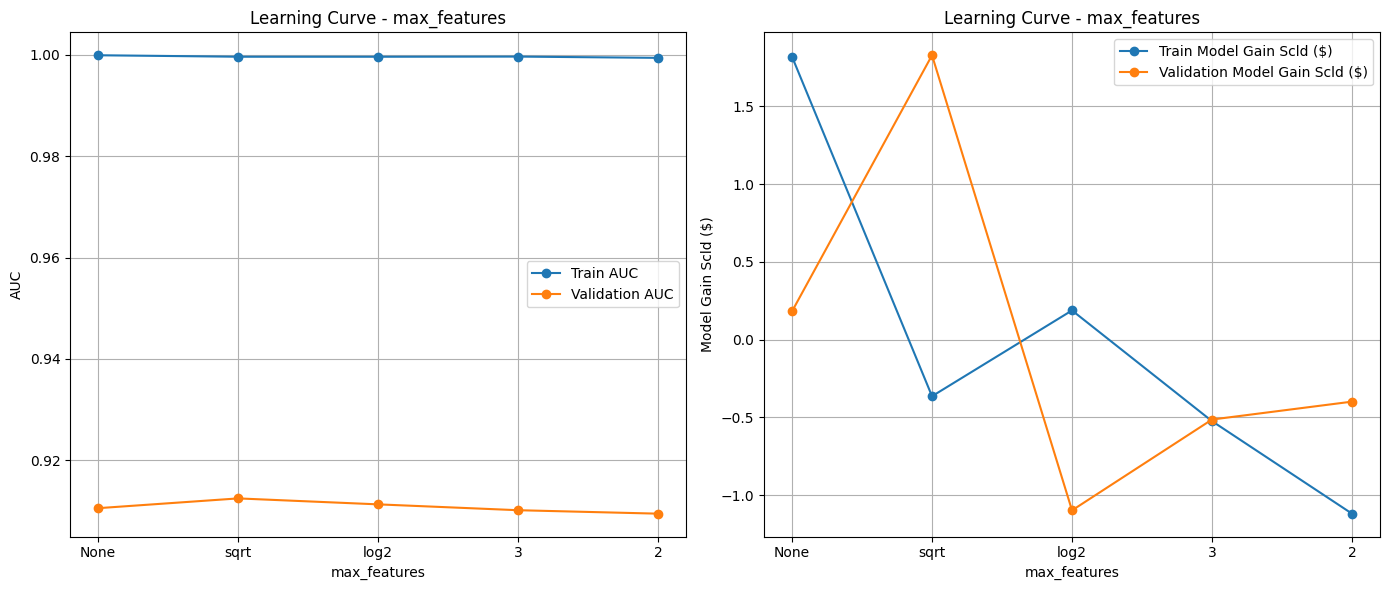

In [ ]:
# Oversampling de clase minoritaria
X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nooh[selected_features],
    sampling_object=SMOTE
)

# Partición en train, validation y test
X_trainval, X_test, y_trainval, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=0, stratify=y_resampled)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=0, stratify=y_trainval)

params_values = {
    "max_depth": range(6,21),
    "n_estimators": range(100,550,50),
    "min_samples_split": range(2, 5),
    "min_samples_leaf": range(2, 5),
    "max_features": [None, "sqrt", "log2", 3, 2]
}

for param, values in params_values.items():
    # Crear listas de scores vacías para cada parámetro
    auc_train_scores = []
    auc_val_scores = []
    eco_train_scores = []
    eco_val_scores = []
    
    # Crear modelo con hiperparámetros default
    model = RandomForestClassifier(n_estimators=450, max_depth=15, min_samples_split=2, min_samples_leaf=2, max_features=2)
    
    for val in values:
        # Setear el valor del parámetro pasado en params_values
        setattr(model, param, val)

        # Entrenar el modelo
        model.fit(X_train, y_train)

        # Calcular y hacer append de AUC en train y validation
        pred_prob_train = model.predict_proba(X_train)[:, 1]
        auc_train = roc_auc_score(y_train, pred_prob_train)
        
        pred_prob_val = model.predict_proba(X_val)[:, 1]
        auc_val = roc_auc_score(y_val, pred_prob_val)

        auc_train_scores.append(auc_train)
        auc_val_scores.append(auc_val)

        # Calcular y hacer append de economic score en train y validation
        pred_train = model.predict(X_train)
        train_cm = confusion_matrix(y_train, pred_train)
        eco_train = mod_prep.economic_score(train_cm, avg_tkt, churn_like, churn_dislike)

        pred_val = model.predict(X_val)
        val_cm = confusion_matrix(y_val, pred_val)
        eco_val = mod_prep.economic_score(val_cm, avg_tkt, churn_like, churn_dislike)

        eco_train_scores.append(eco_train)
        eco_val_scores.append(eco_val)


    eco_train_scores_z = stats.zscore(eco_train_scores)
    eco_val_scores_z = stats.zscore(eco_val_scores)

    # Plotear Learning Curves
    param_scores_pairs = {
        "AUC": [auc_train_scores, auc_val_scores],
        "Model Gain Scld ($)": [eco_train_scores_z, eco_val_scores_z]
    }

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    if None in values:
        none_idx = values.index(None)
        values[none_idx] = "None"

    for i, (metric, pair) in enumerate(param_scores_pairs.items()):
        ax = axes[i]
        ax.plot(values, pair[0], label=f"Train {metric}", marker="o")
        ax.plot(values, pair[1], label=f"Validation {metric}", marker="o")
        ax.set_xlabel(param)
        ax.set_ylabel(f"{metric}")
        ax.set_title(f"Learning Curve - {param}")
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
 # TODO: hacer feature selection para reducir la cantidad de features que son tenidas en cuenta para realizar la predicción.
 # - RevisarKFold para cross validation.
 # - Testeas con data nueva generada de 1000 usuarios (+ data = - Overfitting?)
 # - Feature engineering
 # - Fijate que tastes min y max tienen colinealidad. Quizás podrías hacer un feature engineering y obtener el promedio entre ambos directo. 
 # - Luego podrías evaluar si ese promedio hace sentido ponerlo junto con el taste en si.
 # TODO: pasar el ploteo de curvas de aprendizaje a función.